# Alzheimer's Disease Stage Classification from Brain MRI Images

Classification of Alzheimer's disease stages from MRI brain scans using deep learning.  
Four classes: **NonDemented**, **VeryMildDemented**, **MildDemented**, **ModerateDemented**.

## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_recall_fscore_support, classification_report
)
from tqdm.notebook import tqdm

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: cpu
PyTorch version: 2.12.1+cpu


## 2. Helper Functions

In [2]:
def get_device():
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def bind_gpu(data):
    dev = get_device()
    if isinstance(data, (list, tuple)):
        return [bind_gpu(d) for d in data]
    return data.to(dev, non_blocking=True)


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    for name, layer in model.named_children():
        n = sum(p.numel() for p in layer.parameters())
        print(f"Layer: {name}, Parameters: {n}")
    print(f"Total parameters: {total}")
    return total


def train_model(model, criterion, optimizer, num_epochs, train_loader, val_loader):
    metrics = {
        'train_loss': [], 'train_accuracy': [], 'train_steps': [],
        'val_loss': [], 'val_accuracy': [], 'val_steps': [],
    }
    dev = get_device()
    step = 0

    pbar = tqdm(total=num_epochs, desc='Training')
    for epoch in range(num_epochs):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(dev), labels.to(dev)
            logits = model(inputs)
            loss = criterion(logits, labels)

            predicted = torch.argmax(logits, dim=1)
            acc = (predicted == labels).float().mean().item()

            metrics['train_loss'].append(loss.item())
            metrics['train_accuracy'].append(acc)
            metrics['train_steps'].append(step)
            step += 1

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss, val_correct, val_total = 0.0, 0, 0
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(dev), labels.to(dev)
                logits = model(inputs)
                val_loss += F.cross_entropy(logits, labels, reduction='sum').item()
                val_correct += (torch.argmax(logits, 1) == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total
        metrics['val_loss'].append(val_loss)
        metrics['val_accuracy'].append(val_acc)
        metrics['val_steps'].append(step)

        pbar.set_postfix({'val_loss': f'{val_loss:.4f}', 'val_acc': f'{val_acc:.4f}'})
        pbar.update(1)

    pbar.close()
    return metrics


def plot_metrics(metrics, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    if title:
        fig.suptitle(title, fontsize=13)

    axes[0].plot(metrics['train_steps'], metrics['train_loss'], label='Train Loss', alpha=0.7)
    axes[0].plot(metrics['val_steps'], metrics['val_loss'], label='Validation Loss')
    axes[0].set_xlabel('Training Steps')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend()

    axes[1].plot(metrics['train_steps'], metrics['train_accuracy'], label='Train Accuracy', alpha=0.7)
    axes[1].plot(metrics['val_steps'], metrics['val_accuracy'], label='Validation Accuracy')
    axes[1].set_xlabel('Training Steps')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


CLASS_NAMES = ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']

def evaluate_model(model, criterion, dataloader, title=''):
    model.eval()
    total_loss = 0.0
    predicted_labels, true_labels = [], []
    dev = get_device()

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(dev), labels.to(dev)
            logits = model(inputs)
            total_loss += criterion(logits, labels).item()

            predicted = torch.argmax(logits, dim=1)
            predicted_labels.extend(predicted.tolist())
            true_labels.extend(labels.tolist())

    accuracy = accuracy_score(true_labels, predicted_labels)
    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, predicted_labels, average='weighted', zero_division=0
    )

    if title:
        print(title)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Confusion Matrix' + (f' - {title}' if title else ''))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    avg_loss = total_loss / len(dataloader)
    return avg_loss, accuracy


print("Helper functions defined.")

Helper functions defined.


## 3. Data Loading and Exploratory Data Analysis

In [3]:
DATA_DIR = Path("Alzheimer_s Dataset/data")

CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

image_paths, labels = [], []
for class_name, class_idx in CLASS_TO_IDX.items():
    class_dir = DATA_DIR / class_name
    for img_path in sorted(class_dir.iterdir()):
        image_paths.append(img_path)
        labels.append(class_idx)

print(f"Total images: {len(image_paths)}")
counts = Counter(labels)
for idx, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {counts[idx]}")

Total images: 6400
  NonDemented: 3200
  VeryMildDemented: 2240
  MildDemented: 896
  ModerateDemented: 64


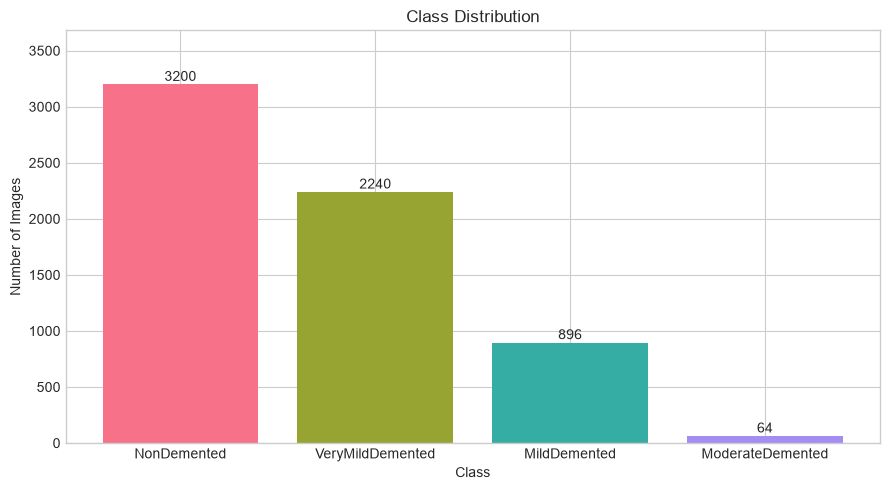

In [4]:
class_counts = [counts[i] for i in range(4)]
colors = sns.color_palette('husl', 4)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(CLASS_NAMES, class_counts, color=colors)

for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            str(count), ha='center')

ax.set_title('Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Images')
ax.set_ylim(0, max(class_counts) * 1.15)
plt.tight_layout()
plt.show()

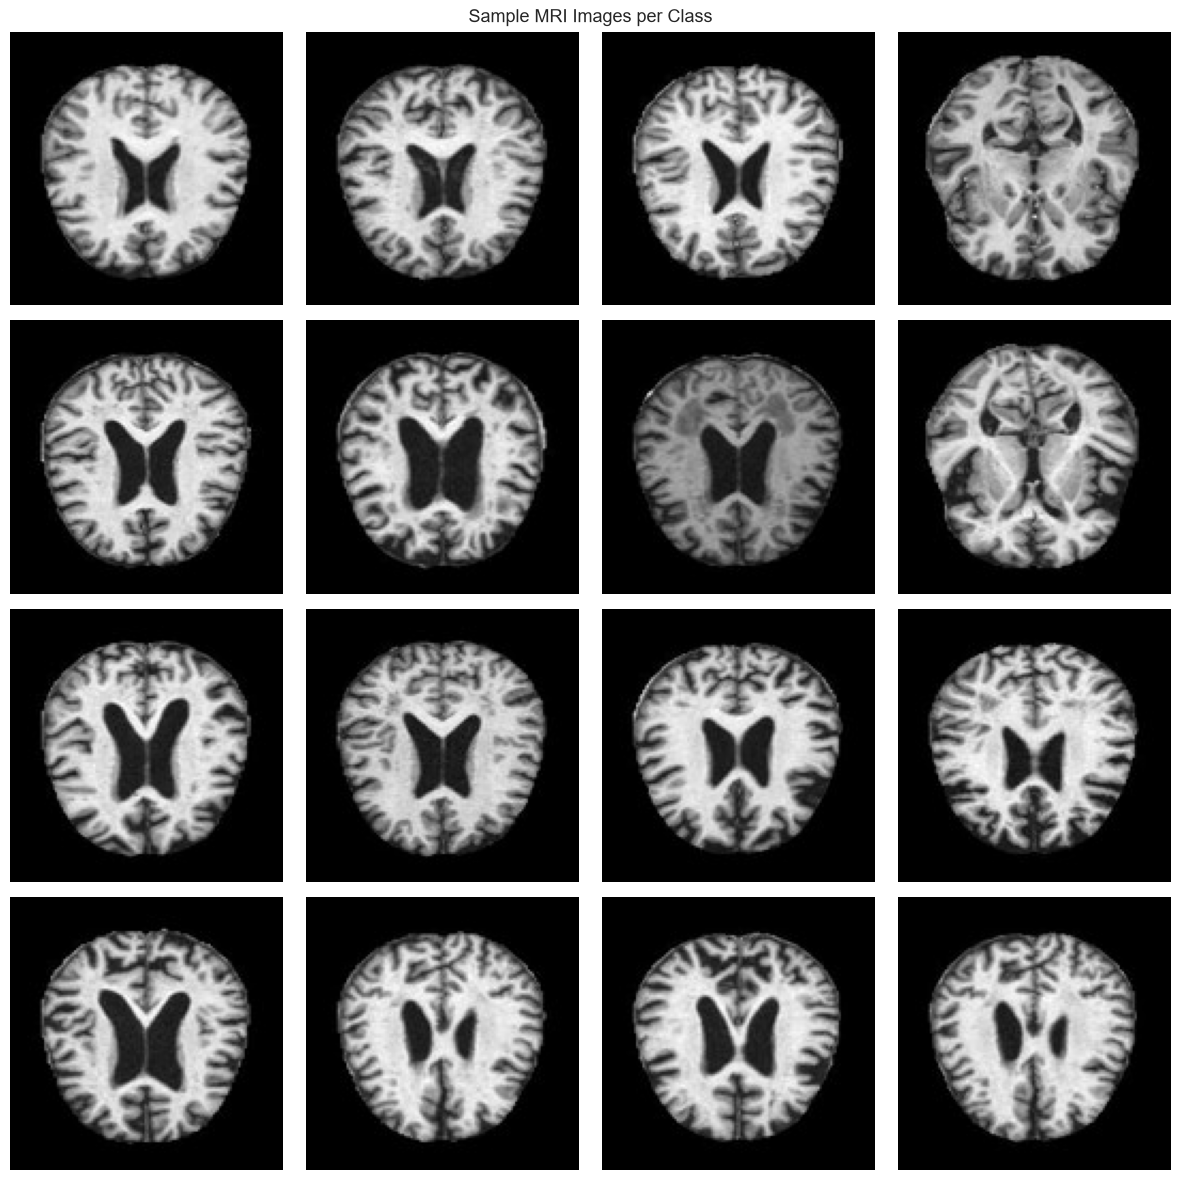

In [5]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Sample MRI Images per Class', fontsize=13)

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_paths = [p for p, l in zip(image_paths, labels) if l == class_idx]
    for col, img_path in enumerate(class_paths[:4]):
        ax = axes[class_idx][col]
        ax.imshow(Image.open(img_path).convert('RGB'))
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(class_name, fontsize=9, rotation=90, labelpad=10)
            ax.yaxis.set_label_position('left')

plt.tight_layout()
plt.show()

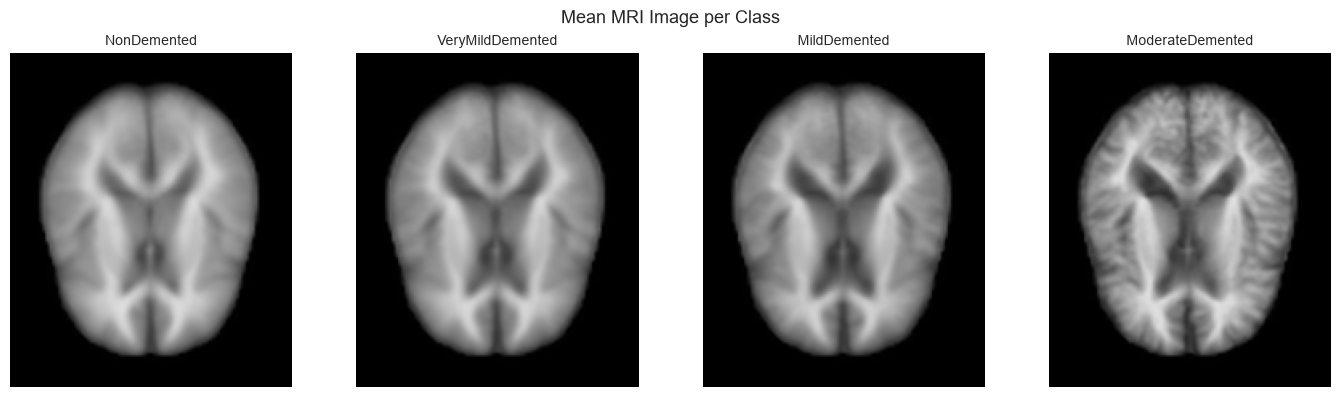

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Mean MRI Image per Class', fontsize=13)

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_paths = [p for p, l in zip(image_paths, labels) if l == class_idx]
    imgs = np.stack([
        np.array(Image.open(p).convert('L').resize((176, 208)), dtype=np.float32)
        for p in class_paths
    ])
    mean_img = imgs.mean(axis=0)
    axes[class_idx].imshow(mean_img, cmap='gray', vmin=0, vmax=255)
    axes[class_idx].set_title(class_name, fontsize=10)
    axes[class_idx].axis('off')

plt.tight_layout()
plt.show()

## 4. Data Augmentation

The dataset is heavily imbalanced — `ModerateDemented` has only 64 images vs 3200 for `NonDemented`.  
We apply augmentation to minority classes to balance the distribution:
- **MildDemented** (896) → target ~2240
- **ModerateDemented** (64) → target ~2240

Augmentation operations: horizontal flip, small rotation, brightness/contrast jitter, slight zoom.

In [7]:
AUG_DIR = Path("Alzheimer_s Dataset/augmented")
AUG_TARGET = 2240

augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
])

def augment_class(class_name, target_count):
    src_dir = DATA_DIR / class_name
    dst_dir = AUG_DIR / class_name
    dst_dir.mkdir(parents=True, exist_ok=True)

    originals = sorted(src_dir.iterdir())
    for p in originals:
        Image.open(p).convert('RGB').save(dst_dir / p.name)

    existing = list(originals)
    needed = target_count - len(existing)
    generated = 0

    while generated < needed:
        src_path = existing[generated % len(existing)]
        aug_img = augment_transform(Image.open(src_path).convert('RGB'))
        aug_img.save(dst_dir / f"aug_{generated}.jpg")
        generated += 1

    print(f"{class_name}: {len(existing)} original -> {len(existing) + generated} total")

print("Generating augmented images...")
for class_name, class_idx in CLASS_TO_IDX.items():
    src_dir = DATA_DIR / class_name
    dst_dir = AUG_DIR / class_name
    original_count = counts[class_idx]
    if original_count >= AUG_TARGET:
        dst_dir.mkdir(parents=True, exist_ok=True)
        for p in sorted(src_dir.iterdir()):
            Image.open(p).convert('RGB').save(dst_dir / p.name)
        print(f"{class_name}: {original_count} (no augmentation needed)")
    else:
        augment_class(class_name, AUG_TARGET)

print("Done.")

Generating augmented images...


NonDemented: 3200 (no augmentation needed)


VeryMildDemented: 2240 (no augmentation needed)


MildDemented: 896 original -> 2240 total


ModerateDemented: 64 original -> 2240 total
Done.


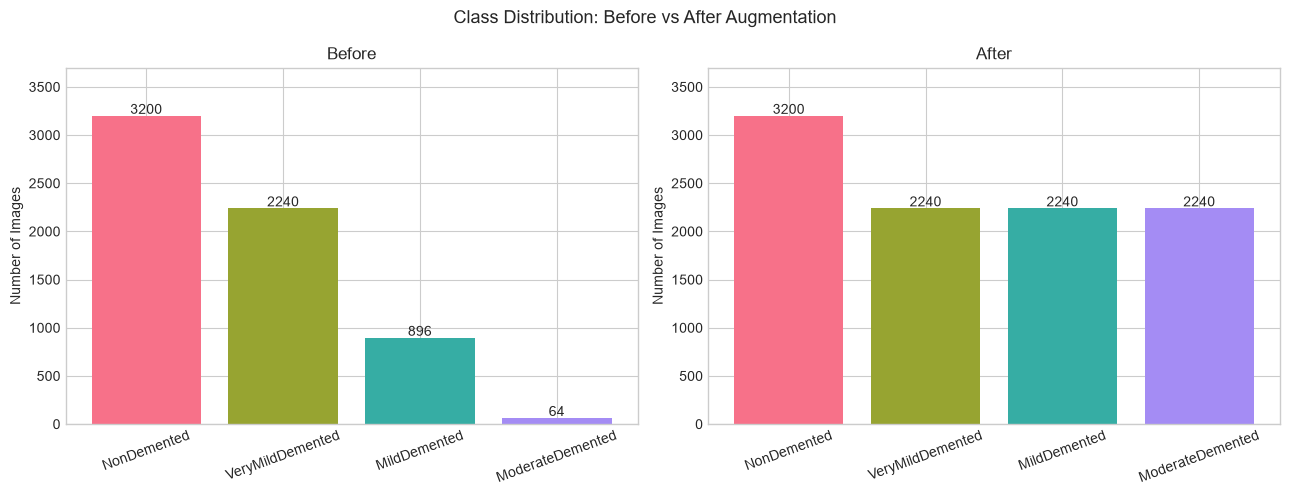

Total images after augmentation: 9920


In [8]:
aug_counts = {}
for class_name in CLASS_NAMES:
    aug_counts[class_name] = len(list((AUG_DIR / class_name).iterdir()))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Class Distribution: Before vs After Augmentation', fontsize=13)
colors = sns.color_palette('husl', 4)

bars1 = axes[0].bar(CLASS_NAMES, [counts[i] for i in range(4)], color=colors)
for bar, cnt in zip(bars1, [counts[i] for i in range(4)]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(cnt), ha='center')
axes[0].set_title('Before')
axes[0].set_ylabel('Number of Images')
axes[0].set_ylim(0, 3700)
axes[0].tick_params(axis='x', rotation=20)

bars2 = axes[1].bar(CLASS_NAMES, [aug_counts[n] for n in CLASS_NAMES], color=colors)
for bar, cnt in zip(bars2, [aug_counts[n] for n in CLASS_NAMES]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(cnt), ha='center')
axes[1].set_title('After')
axes[1].set_ylabel('Number of Images')
axes[1].set_ylim(0, 3700)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

total_aug = sum(aug_counts.values())
print(f"Total images after augmentation: {total_aug}")

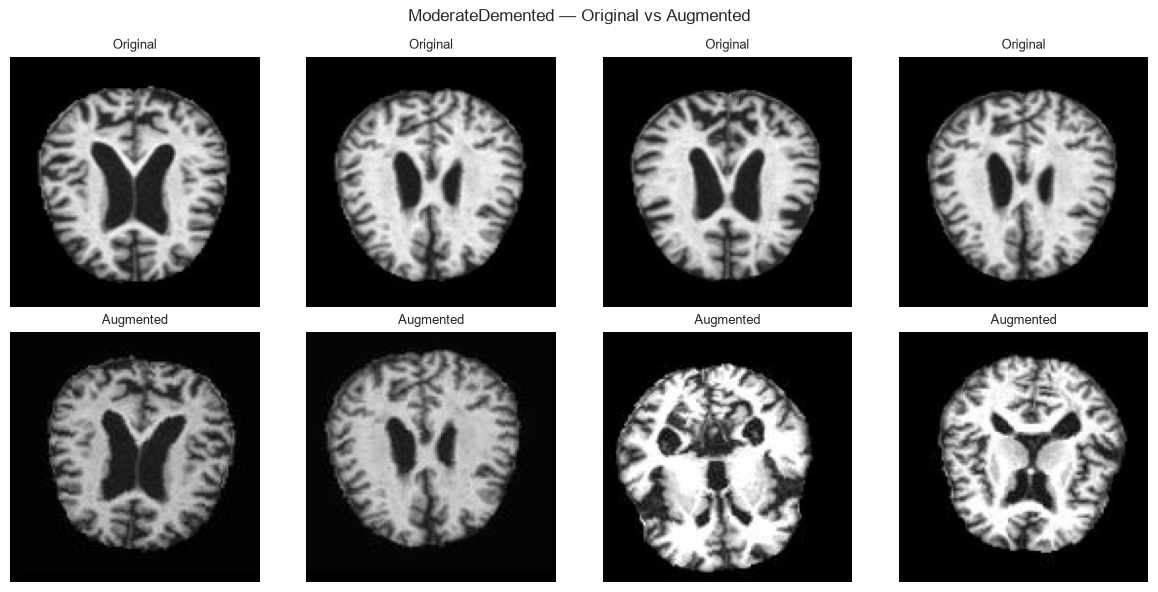

In [9]:
orig_paths = sorted((DATA_DIR / 'ModerateDemented').iterdir())[:4]
aug_only_paths = sorted((AUG_DIR / 'ModerateDemented').glob('aug_*.jpg'))[:4]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('ModerateDemented — Original vs Augmented', fontsize=12)

for col, p in enumerate(orig_paths):
    axes[0][col].imshow(Image.open(p).convert('RGB'))
    axes[0][col].axis('off')
    axes[0][col].set_title('Original', fontsize=9)

for col, p in enumerate(aug_only_paths):
    axes[1][col].imshow(Image.open(p).convert('RGB'))
    axes[1][col].axis('off')
    axes[1][col].set_title('Augmented', fontsize=9)

plt.tight_layout()
plt.show()